# Anomaly-Based Network Intrusion Detection System
## Notebook 01: Data Exploration and Analysis

**Author:** Deepanshu Garhkoti  
**Date:** September 15, 2026  
**Dataset:** UNSW-NB15  

### Objectives
1. Load and inspect the UNSW-NB15 dataset
2. Analyse data quality and missing values
3. Examine feature distributions and correlations
4. Investigate class imbalance and attack-type distribution
5. Generate visualisations for better understanding

## 1. Imports and Setup

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join('..'))
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

from src.data.loader import DataLoader
from src.utils.visualization import plot_class_distribution, plot_correlation_matrix

print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Load Data

In [2]:
loader = DataLoader(dataset='unsw_nb15')
df = loader.load_raw_data()

print(f'Shape : {df.shape}')
print(f'Samples : {df.shape[0]:,}')
print(f'Features: {df.shape[1]}')
df.head()

Shape : (175341, 45)
Samples : 175,341
Features: 45


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.1215,tcp,-,FIN,6,4,258,172,74.0875,252,254,14158.9424,8495.3652,0,0,24.2956,8.3750,30.1775,11.8306,255,621772692,2202533631,255,0.0000,0.0000,0.0000,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,Normal,0
1,2,0.6499,tcp,-,FIN,14,38,734,42014,78.4734,62,252,8395.1123,503571.3125,2,17,49.9150,15.4329,61.4269,1387.7783,255,1417884146,3077387971,255,0.0000,0.0000,0.0000,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,Normal,0
2,3,1.6231,tcp,-,FIN,8,16,364,13186,14.1702,62,252,1572.2719,60929.2305,1,6,231.8756,102.7372,17179.5869,11420.9262,255,2116150707,2963114973,255,0.1119,0.0615,0.0504,46,824,0,0,7,1,2,1,1,3,0,0,0,2,6,0,Normal,0
3,4,1.6816,tcp,ftp,FIN,12,12,628,770,13.6771,62,252,2740.1790,3358.6221,1,3,152.8765,90.2357,259.0802,4991.7847,255,1107119177,1047442890,255,0.0000,0.0000,0.0000,52,64,0,0,1,1,2,1,1,3,1,1,0,2,1,0,Normal,0
4,5,0.4495,tcp,-,FIN,10,6,534,268,33.3738,254,252,8561.4990,3987.0598,2,1,47.7503,75.6596,2415.8376,115.8070,255,2436137549,1977154190,255,0.1284,0.0711,0.0572,53,45,0,0,43,1,2,2,1,40,0,0,0,2,39,0,Normal,0


## 3. Data-Quality Check

In [3]:
missing = df.isnull().sum()
missing_pct = missing / len(df) * 100
quality = pd.DataFrame({'Missing': missing, 'Missing %': missing_pct})
quality = quality[quality['Missing'] > 0].sort_values('Missing', ascending=False)

if quality.empty:
    print('No missing values found')
else:
    print(f'{len(quality)} columns with missing values')
    display(quality)

dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes} ({dupes/len(df)*100:.2f}%)')

No missing values found


Duplicate rows: 0 (0.00%)


## 4. Target Variable Analysis

Binary label distribution:


,Count,Percent
label,,
1,119341,68.0622
0,56000,31.9378


Imbalance ratio: 2.13


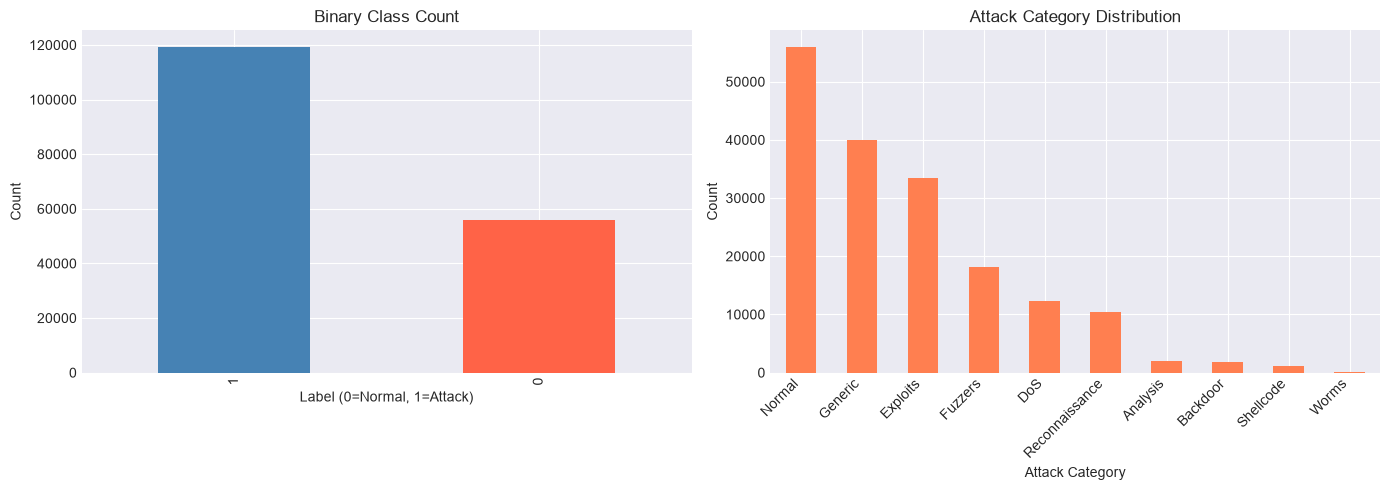

In [4]:
TARGET = 'label'   # binary: 0=normal, 1=attack
CAT_TARGET = 'attack_cat'  # multi-class attack category

print('Binary label distribution:')
label_counts = df[TARGET].value_counts()
label_pct = df[TARGET].value_counts(normalize=True) * 100
display(pd.DataFrame({'Count': label_counts, 'Percent': label_pct}))

print(f'Imbalance ratio: {label_counts.max()/label_counts.min():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
label_counts.plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Binary Class Count')
axes[0].set_xlabel('Label (0=Normal, 1=Attack)')
axes[0].set_ylabel('Count')

if CAT_TARGET in df.columns:
    cat_counts = df[CAT_TARGET].value_counts()
    cat_counts.plot(kind='bar', ax=axes[1], color='coral')
    axes[1].set_title('Attack Category Distribution')
    axes[1].set_xlabel('Attack Category')
    axes[1].set_ylabel('Count')
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 5. Numeric Feature Statistics

In [5]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Numeric: {len(num_cols)}  |  Categorical: {len(cat_cols)}')

display(df[num_cols[:15]].describe().T)

Numeric: 41  |  Categorical: 4


,count,mean,std,min,25%,50%,75%,max
id,175341.0000,87671.0000,50616.7311,1.0000,43836.0000,87671.0000,131506.0000,175341.0000
dur,175341.0000,1.3594,6.4802,0.0000,0.0000,0.0016,0.6681,60.0000
spkts,175341.0000,20.2987,136.8876,1.0000,2.0000,2.0000,12.0000,9616.0000
dpkts,175341.0000,18.9696,110.2583,0.0000,0.0000,2.0000,10.0000,10974.0000
sbytes,175341.0000,8844.8438,174765.6443,28.0000,114.0000,430.0000,1418.0000,12965233.0000
dbytes,175341.0000,14928.9186,143654.2177,0.0000,0.0000,164.0000,1102.0000,14655550.0000
rate,175341.0000,95406.1871,165400.9785,0.0000,32.7861,3225.8065,125000.0003,1000000.0030
sttl,175341.0000,179.5470,102.9400,0.0000,62.0000,254.0000,254.0000,255.0000
dttl,175341.0000,79.6096,110.5069,0.0000,0.0000,29.0000,252.0000,254.0000
sload,175341.0000,73454033.1941,188357447.0002,0.0000,13053.3389,879674.7500,88888888.0000,5988000256.0000


## 6. Correlation Matrix

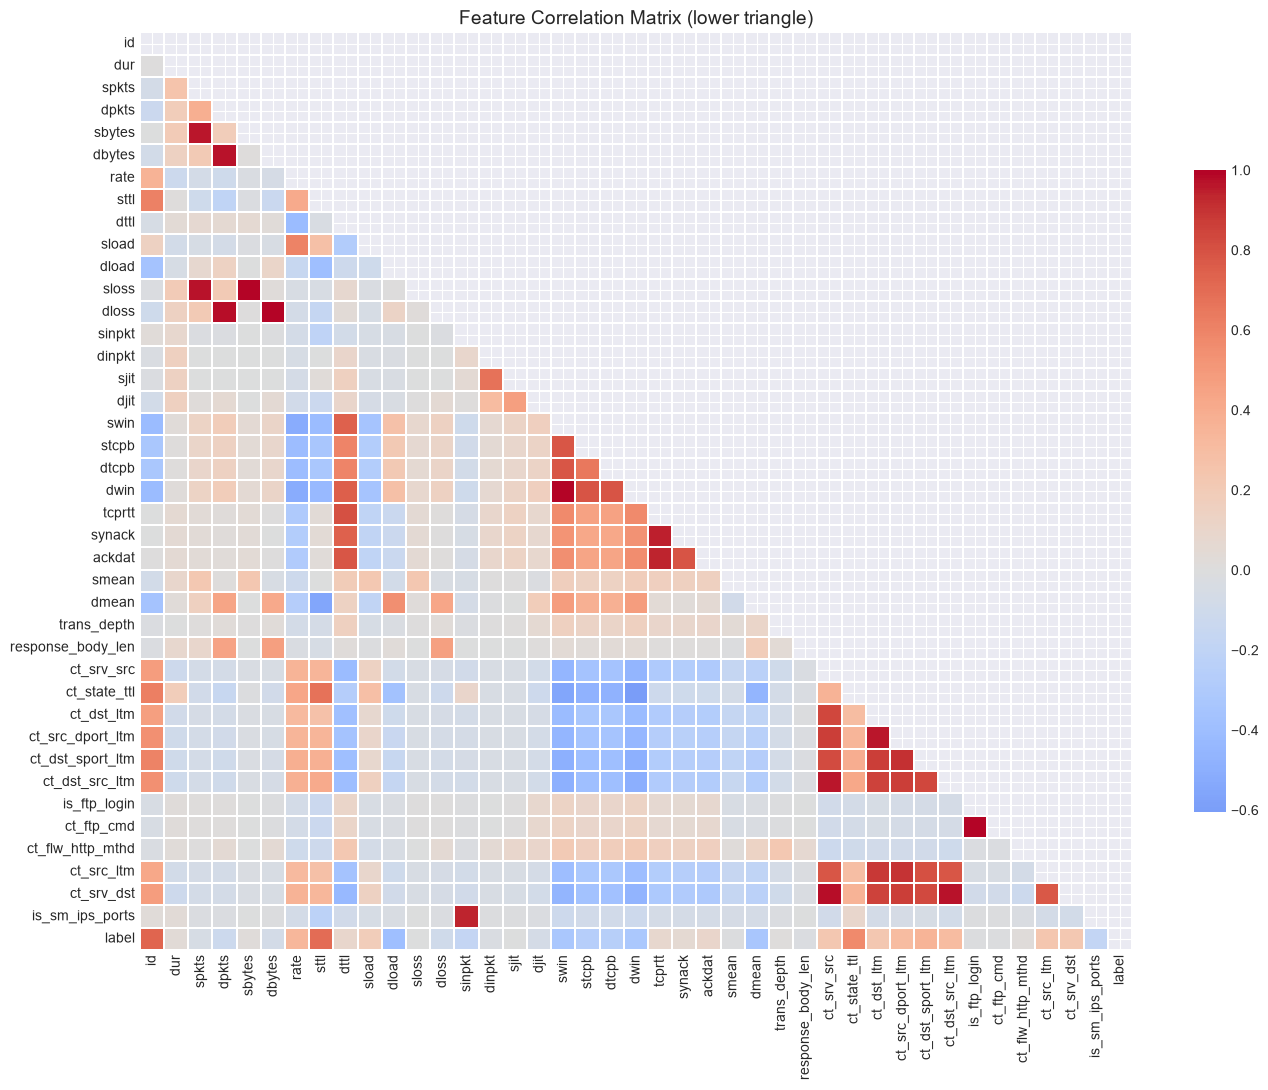

Highly correlated pairs (|r|>0.85): 24
  is_ftp_login  <->  ct_ftp_cmd  : 1.000
  dbytes  <->  dloss  : 0.997
  sbytes  <->  sloss  : 0.996
  swin  <->  dwin  : 0.990
  ct_srv_src  <->  ct_srv_dst  : 0.980
  dpkts  <->  dloss  : 0.979
  ct_dst_src_ltm  <->  ct_srv_dst  : 0.972
  dpkts  <->  dbytes  : 0.972
  spkts  <->  sloss  : 0.971
  ct_srv_src  <->  ct_dst_src_ltm  : 0.967


In [6]:
corr = df[num_cols].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, cbar_kws={'shrink': 0.7})
plt.title('Feature Correlation Matrix (lower triangle)', fontsize=14)
plt.tight_layout()
plt.show()

high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.85:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print(f'Highly correlated pairs (|r|>0.85): {len(high_corr)}')
for a, b, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True)[:10]:
    print(f'  {a}  <->  {b}  : {r:.3f}')

## 7. Observations and Next Steps

In [7]:
print('Key observations:')
print('  - Dataset shape and missing values reviewed above')
print('  - Binary class imbalance ratio documented')
print('  - Highly correlated features identified for potential removal')
print()
print('Next: 02_preprocessing.ipynb')

Key observations:
  - Dataset shape and missing values reviewed above
  - Binary class imbalance ratio documented
  - Highly correlated features identified for potential removal

Next: 02_preprocessing.ipynb
